# Energy Scheduling

This tutorial builds a real-world energy-scheduling problem end to end. We assemble electricity load, day-ahead price, and climate data into a single dataset, formulate the scheduling problem as a linear program over flexible demand, and train a predict-then-optimize model that schedules that demand against predicted prices.

This Jupyter Notebook has been modified from code originally developed by [Angel Paredes](https://scholar.google.com/citations?hl=en&user=bAMNXzYAAAAJ) and [Pietro Favaro](https://scholar.google.com/citations?hl=en&user=p-zTDnMAAAAJ). Thanks for their contributions.

## Install (Colab Only)

In [1]:
# download simbench
!git clone https://github.com/e2nIEE/simbench.git
# install aiopvpc
!pip install aiopvpc
# install meteostat
!pip install meteostat==1.6.8
# install pyepo
!pip install pyepo
# install
!pip install gurobipy

Cloning into 'simbench'...
remote: Enumerating objects: 1375, done.
remote: Counting objects: 100% (160/160), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 1375 (delta 125), reused 132 (delta 115), pack-reused 1215 (from 1)
Receiving objects: 100% (1375/1375), 67.37 MiB | 7.84 MiB/s, done.
Resolving deltas: 100% (899/899), done.
Updating files: 100% (165/165), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.9/157.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully uninstalled dill-0.3.8
  Attempting uninstall: multiprocess
    Found existing installatio

Remove a Google Colab import hook that interferes with PyEPO.

In [2]:
import sys
sys.meta_path = [hook for hook in sys.meta_path if not any(keyword in str(hook) for keyword in ["google.colab"])]

In [3]:
# set random seed
import random
random.seed(42)
import numpy as np
np.random.seed(42)
import torch
torch.manual_seed(42)
torch.cuda.manual_seed(42)

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## 1 Data

### 1.1 Energy Load Data

SimBench ([simbench.net](https://www.simbench.net)) provides standardized simulation datasets for power system analysis.

In [5]:
import pandas as pd

# load the dataset from a CSV file
df = pd.read_csv('./simbench/simbench/networks/1-complete_data-mixed-all-0-sw/LoadProfile.csv',sep=';')
print('The size of the dataset is ({:},{:})'.format(len(df.index),len(df.columns)))
display(df.head())

The size of the dataset is (35136,193)


,time,BL-H_qload,BL-H_pload,G0-A_qload,G0-A_pload,G0-M_qload,G0-M_pload,G1-A_qload,G1-A_pload,G1-B_qload,...,HS25_pload,HS25_qload,HS26_pload,HS26_qload,HS27_pload,HS27_qload,HSexp0_pload,HSexp0_qload,HSexp1_pload,HSexp1_qload
0,01.01.2016 00:00,0.143050,0.088339,0.282542,0.143882,0.256264,0.275641,0.056108,0.039528,0.000000,...,0.652520,0.214473,0.653424,0.214770,0.446373,0.146716,0.806813,0.265187,0.966765,0.317760
1,01.01.2016 00:15,0.169872,0.084806,0.389736,0.203032,0.473602,0.283333,0.007014,0.026333,0.021812,...,0.653845,0.214909,0.651595,0.214169,0.441562,0.145134,0.806813,0.265187,0.962273,0.316284
2,01.01.2016 00:30,0.169872,0.077739,0.402408,0.213184,0.376287,0.248718,0.008837,0.027719,0.021812,...,0.655171,0.215344,0.649767,0.213568,0.436751,0.143553,0.806813,0.265187,0.957781,0.314807
3,01.01.2016 00:45,0.151991,0.081272,0.329803,0.170953,0.434676,0.269231,0.012344,0.029826,0.010906,...,0.656496,0.215780,0.647938,0.212967,0.431940,0.141972,0.806813,0.265187,0.953289,0.313331
4,01.01.2016 01:00,0.151991,0.081272,0.385284,0.191256,0.437920,0.271795,0.007014,0.027054,0.000000,...,0.657822,0.216216,0.646110,0.212366,0.427129,0.140390,0.806813,0.265187,0.948797,0.311855


In [6]:
# set 'time' as the index and select the 'mv_comm_pload' column
df_load = df.set_index("time").loc[:,"mv_comm_pload"]
# convert the datetime format
df_load.index = pd.to_datetime(df_load.index, format="%d.%m.%Y %H:%M")
# remove the index name
df_load.index.name = None
# resample to 1h resolution
df_load = df_load.resample("1h").mean()
# rename the column
df_load = df_load.rename('load')
# to dataframe
df_load = pd.DataFrame(df_load)
# display
print()
display(df_load.head())

,load
2016-01-01 00:00:00,0.160756
2016-01-01 01:00:00,0.166248
2016-01-01 02:00:00,0.149171
2016-01-01 03:00:00,0.140763
2016-01-01 04:00:00,0.132669


### 1.2 Price Data

We use [aiopvpc](https://github.com/azogue/aiopvpc), a small async library, to download Spanish hourly electricity prices.

In [7]:
from datetime import datetime, timedelta
# base date to start data
base = datetime(2022, 1, 1)
# number of days to import starting from base
date_list = [base + timedelta(days=x) for x in range(366)]

In [8]:
import aiohttp
from aiopvpc import PVPCData

# empty DataFrame
df_price = pd.DataFrame(columns=["time", "price"])

# retrieve the price data
async with aiohttp.ClientSession() as session:
    for h in date_list:
        # init the PVPCData handle
        pvpc_handler = PVPCData(session=session, tariff="2.0TD")
        # retrieve the data for the current date
        esios_data = await pvpc_handler.async_update_all(
             current_data=None, now=h
        )
        # extract time and price
        k = [str(k) for k in esios_data.sensors["PVPC"].keys()]
        p = [v for v in esios_data.sensors["PVPC"].values()]
        p_i = pd.DataFrame({"time": k, "price": p})
        # add to df
        df_price = pd.concat([df_price, p_i])

# display
display(df_load.head())

,load
2016-01-01 00:00:00,0.160756
2016-01-01 01:00:00,0.166248
2016-01-01 02:00:00,0.149171
2016-01-01 03:00:00,0.140763
2016-01-01 04:00:00,0.132669


### 1.3 Climate Data

The Meteostat Python library (https://dev.meteostat.net/python) provides simple access to open weather and climate data using Pandas.

In [9]:
from meteostat import Stations, Hourly
# time period
start = datetime(2022, 1, 1)
end = datetime(2023, 1, 3)
# station object for Spain
stations = Stations().region("ES")
# get hourly data for 2022
data = Hourly(stations.fetch(), start, end)
# normalize data
data = data.normalize()
# aggregate data spatially
data = data.aggregate(freq="1h", spatial=True)
# fetch data
df_climate = data.fetch()
# display
display(df_climate.head())

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2022-01-01 00:00:00,10.1,5.0,75.2,0.0,NaN,160.3,7.9,20.9,1026.9,0.0,2.2
2022-01-01 01:00:00,9.9,4.6,74.7,0.0,NaN,158.1,8.0,22.0,1026.7,0.0,2.2
2022-01-01 02:00:00,9.6,4.5,75.2,0.0,NaN,168.2,7.9,21.6,1026.7,0.0,2.1
2022-01-01 03:00:00,9.4,4.0,74.0,0.0,NaN,156.0,7.9,21.8,1026.7,0.0,2.4
2022-01-01 04:00:00,9.1,3.7,73.8,0.0,NaN,154.6,7.7,20.9,1026.6,0.0,2.4


### 1.4 Joint Dataset for Training

In [10]:
# random flexibility bound of demand
plo_t = df_load.load.values * (0.7 + 0.1 * np.random.rand(df_load.values.size)) # lower bound
pup_t = df_load.load.values * (1.2 + 0.1 * np.random.rand(df_load.values.size)) # upper bound
# joint dataset
df = pd.DataFrame({"pi_t": df_price.price.values,                               # price
                   "temp": df_climate.temp.values[:df_price.shape[0]],          # temperature
                   "rhum": df_climate.rhum.values[:df_price.shape[0]],          # relative humidity
                   "wdir": df_climate.wdir.values[:df_price.shape[0]],          # wind direction
                   "wspd": df_climate.wspd.values[:df_price.shape[0]],          # wind speed
                   "pres": df_climate.pres.values[:df_price.shape[0]],          # pressure
                   "tsun": df_climate.tsun.values[:df_price.shape[0]],          # number of minutes of sunshine in the hour
                   "Psch_t": df_load.load.values,                               # scheduled load
                   "Plo_t": plo_t,                                              # flexibility lower bound of load
                   "Pup_t": pup_t                                               # flexibility upper bound of load
    })
display(df.head())

,pi_t,temp,rhum,wdir,wspd,pres,tsun,Psch_t,Plo_t,Pup_t
0,0.20451,10.1,75.2,160.3,7.9,1026.9,0.0,0.160756,0.118550,0.202013
1,0.17135,9.9,74.7,158.1,8.0,1026.7,0.0,0.166248,0.132179,0.207341
2,0.17270,9.6,75.2,168.2,7.9,1026.7,0.0,0.149171,0.115339,0.186401
3,0.15607,9.4,74.0,156.0,7.9,1026.7,0.0,0.140763,0.106961,0.179223
4,0.15908,9.1,73.8,154.6,7.7,1026.6,0.0,0.132669,0.094938,0.160367


In [11]:
def nanFill(x):
    """
    A function to replaces NaN values with the mean of the previous and next values.
    """
    if x.ndim == 2:
        # iterate over columns in a 2D array
        for j in range(x.shape[1]):
            # get index of nan
            nan_indices = np.where(np.isnan(x[:, j]))[0]
            for i in nan_indices:
                # fill nan by mean
                if 0 < i < len(x) - 1:
                    x[i, j] = np.nanmean([x[i - 1, j], x[i + 1, j]])
                # boundary cases
                elif i == 0:
                    x[i, j] = x[i + 1, j]
                elif i == len(x) - 1:
                    x[i, j] = x[i - 1, j]
    elif x.ndim == 3:
        # iterate over 3rd dimension in a 3D array
        for k in range(x.shape[2]):
            for j in range(x.shape[1]):
                # get index of nan
                nan_indices = np.where(np.isnan(x[:, j, k]))[0]
                for i in nan_indices:
                    # fill nan by mean
                    if 0 < i < len(x) - 1:
                        x[i, j, k] = np.nanmean([x[i - 1, j, k], x[i + 1, j, k]])
                    # boundary cases
                    elif i == 0:
                        x[i, j, k] = x[i + 1, j, k]
                    elif i == len(x) - 1:
                        x[i, j, k] = x[i - 1, j, k]
    return x

In [12]:
# get features
df_feat = df[["pi_t", "temp", "wdir"]].reset_index(drop=True)
# features and costs
lookback_window = 3
# observable features (price, temperature, and wind direction for previous day)
x = np.array([df_feat.iloc[d * 24:(d + lookback_window) * 24, :].values for d in range(0, 365 - lookback_window)])
x = nanFill(x)
# reshape the 3D arrays to 2D arrays
x = x.reshape(x.shape[0], -1)
# labeled costs (true electricity price vector for tomorrow)
c = np.array([df.iloc[d * 24:(d + 1) * 24, 1].values for d in range(lookback_window, 365)])
c = nanFill(c)
# get the flexibility bounds and scheduled load
plo_t = df.loc[:23, 'Plo_t'].values
psch_t = df.loc[:23, 'Psch_t'].values
pup_t = df.loc[:23, 'Pup_t'].values

In [13]:
# data split
from sklearn.model_selection import train_test_split
x_train, x_test, c_train, c_test = train_test_split(x, c, test_size=30, random_state=246)
print("x_train.shape:", x_train.shape)
print("x_test.shape:", x_test.shape)
print("c_train.shape:", c_train.shape)
print("c_test.shape:", c_test.shape)

x_train.shape: (332, 216)
x_test.shape: (30, 216)
c_train.shape: (332, 24)
c_test.shape: (30, 24)


## 2 Optimization Model

Let $\pi_t$ be the price of the next day electricity market for all time steps $t\in\Omega_t$. A demand response program wants to schedule its consumption $p_t$ between a lower $\underline{P}_t$ and upper $\overline{P}_t$ bound for the next day without knowing the actual price. Demand can shift between time steps, but the daily total $\sum_t P_t^{sch}$ must stay constant.

The optimization problem with perfect information is:

$$\min_{p_t} \sum_t \pi_t p_t$$
$$s.t. \quad \underline{P}_t \leq p_t \leq \overline{P}_t, \hspace{10pt} \forall t \\
\sum_t p_t = \sum_t P_t^{sch}
$$


In [14]:
from pyepo import dsl

# minimize price . consumption; total demand fixed, per-hour flexibility bounds
p = dsl.Variable(24, lb=plo_t, ub=pup_t)
pi = dsl.Parameter(24)
optmodel = dsl.Problem(dsl.Minimize(pi @ p), [p.sum() == psch_t.sum()]).compile(backend="gurobi")

Restricted license - for non-production use only - expires 2027-11-29


In [15]:
# solve model (just test)
optmodel.setObj(c_test[0]) # set objective function
sol, obj = optmodel.solve() # solve
# print res
print('Obj: {}'.format(obj))
print('Sol: {}'.format(sol))

Obj: 126.18739122588391
Sol: [0.20201344 0.20734108 0.18640139 0.17922344 0.16036727 0.14570371
 0.16781868 0.16711281 0.17530921 0.17114743 0.10355415 0.14040012
 0.16840809 0.17103557 0.18135329 0.18394221 0.17464827 0.22911266
 0.19452466 0.20723267 0.27147243 0.26636024 0.23349256 0.19769213]


## 3 Dataset and Data Loader

``optDataset`` extends PyTorch ``Dataset`` and uses ``optModel`` to compute optimal solutions for each instance. See the [optDataset tutorial](https://github.com/khalil-research/PyEPO/blob/main/notebooks/02%20Optimization%20Dataset.ipynb) for details.

In [16]:
import pyepo
# get training data set
dataset_train = pyepo.data.dataset.optDataset(optmodel, x_train, c_train)
# get test data set
dataset_test = pyepo.data.dataset.optDataset(optmodel, x_test, c_test)

100%|██████████| 30/30 [00:00<00:00, 4308.77it/s]


In [17]:
# get data loader
from torch.utils.data import DataLoader
batch_size = 4
loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)

## 4 Linear Regression on PyTorch

In PyTorch, the ``nn.Module`` is a base class for all neural network modules. It provides a convenient way to organize the layers of a model and define the forward pass.

Here, we build an MLP with a hidden layer.

In [18]:
import torch
from torch import nn

class multiLayerPerceptron(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(multiLayerPerceptron, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = self.layer2(x)
        return x

In [19]:
# model size
input_dim = x.shape[-1]
output_dim = c.shape[-1]
hidden_dim = 48
# init for test
reg = multiLayerPerceptron(input_dim, hidden_dim, output_dim)

## 5 Training and Testing

PyEPO provides several methods to train the prediction model end-to-end with the embedded optimization layer.

### 5.1 Visualization Functions

In [20]:
import matplotlib.pyplot as plt
from matplotlib import cm

In [21]:
def visSol(plo_t, pup_t, data_loader, optmodel, ind=0,
           pytorch_model=None, sklearn_model=None, method_name=None):
    # iterating over data loader
    for i, data in enumerate(data_loader):
        if i == ind:
            # load data
            x, c, w, z = data
            # move to GPU if available
            if torch.cuda.is_available():
                x = x.cuda()
            # convert to numpy
            c = c.cpu().detach().numpy()[0]
            w = w.cpu().detach().numpy()[0]
            z = z.cpu().detach().numpy()[0]
            # predict with pytorch
            if pytorch_model is not None:
                cp = pytorch_model(x)
                cp = cp.cpu().detach().numpy()[0]
            # predict with sklearn
            elif sklearn_model is not None:
                x = x.cpu().detach().numpy()
                cp = sklearn_model.predict(x)[0]
            # ground truth
            else:
                cp = c
            # plot
            fig = plotSol(c, cp, plo_t, pup_t, ind, method_name)
            break

In [22]:
# plot function
def plotSol(c, cp, plo_t, pup_t, ind, method):
    # solve get optimal solution
    optmodel.setObj(c)
    w, _ = optmodel.solve()
    optmodel.setObj(cp)
    wp, _ = optmodel.solve()
    # calculate total cost
    total_cost = np.sum(c * wp)
    # hours
    t = range(24)
    # plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    # figure 1: price
    axs[0].plot(t, cp, color="b", linewidth=2, linestyle="--", label="Predicted Price")
    axs[0].plot(t, c, color="orange", linewidth=2, label="True Price")
    axs[0].legend(loc="upper left", shadow=False)
    axs[0].set_xlabel("Time (Hour)", fontsize=12)
    axs[0].set_ylabel("Price (€/kWh)", fontsize=12)
    axs[0].set_title("Price Prediction")
    # figure 2: load
    axs[1].plot(t, plo_t, color="r", linewidth=1, alpha=0.8, label="Bounds")
    axs[1].plot(t, pup_t, color="r", alpha=0.8, linewidth=1)
    axs[1].plot(t, wp, color="b", linewidth=2, linestyle="--", marker=".", label="Predicted Load", zorder=4)
    axs[1].plot(t, w, color="orange", linewidth=2, marker=".", label="True Load")
    axs[1].legend(loc="upper left", shadow=False)
    axs[1].set_xlabel("Time (Hour)", fontsize=12)
    axs[1].set_ylabel("Demand (p.u.)", fontsize=12)
    axs[1].set_title("Load Decision")
    # add title
    fig.suptitle("Instance {}, Total Cost for {}: {:.2f}".format(ind, method, total_cost))
    plt.show()

In [23]:
def plotLearningCurve(logs, method):
    # plot
    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False)
    # figure 1: loss
    axs[0].plot(logs["loss"], color="c", linewidth=1)
    # set the x and y axis tick parameters
    axs[0].tick_params(axis="x", labelsize=10)
    axs[0].tick_params(axis="y", labelsize=10)
    # set the x axis limits
    axs[0].set_xlim(-1, len(logs["loss"])+1)
    # set the labels and title
    axs[0].set_xlabel("Iters", fontsize=12)
    axs[0].set_ylabel("Loss", fontsize=12)
    axs[0].set_title("Loss Curve on Training Set")
    # figure 2: regret
    axs[1].plot(100*logs["regret_train"], color="c", linewidth=2, label="Training")
    axs[1].plot(100*logs["regret_test"], color="g", linewidth=2, label="Test")
    # set the x and y axis tick parameters
    axs[1].tick_params(axis="x", labelsize=10)
    axs[1].tick_params(axis="y", labelsize=10)
    # set the x axis limits
    axs[1].set_xlim(-0.2, len(logs["regret_train"])-1+0.2)
    axs[1].set_ylim(0, 5)
    # set the labels and title
    axs[1].set_xlabel("Epochs", fontsize=12)
    axs[1].set_ylabel("Regret (%)", fontsize=12)
    axs[1].legend(loc="upper right", shadow=False)
    axs[1].set_title("Regret Curve on Training and Test Set")
    # add title
    fig.suptitle("Learning Curve for {}, Training Time: {:.2f} sec".format(method, logs["elapsed"]))
    plt.show()

### 5.2 Training

In [24]:
import time
from tqdm import tqdm

def trainModel(reg, func, method_name, loader_train, loader_test, optmodel,
                device="cpu", lr=1e-1, num_epochs=1):
    """
    Train a model using PyEPO.
    """
    # set optimizer
    optimizer = torch.optim.Adam(reg.parameters(), lr=lr)
    # init loss functions
    l1 = nn.L1Loss()
    l2 = nn.MSELoss()
    # set model to training mode
    reg.train()
    # init log
    loss_log = []
    regret_log_train = [pyepo.metric.regret(reg, optmodel, loader_train)]
    regret_log_test = [pyepo.metric.regret(reg, optmodel, loader_test)]
    tbar = tqdm(range(num_epochs))
    elapsed = 0
    for epoch in tbar:
        # eval
        regret_train = pyepo.metric.regret(reg, optmodel, loader_train)
        regret_log_train.append(regret_train)
        regret_test = pyepo.metric.regret(reg, optmodel, loader_test)
        regret_log_test.append(regret_test)
        # record time elapsed for training
        tick = time.time()
        # iterate over data mini-batches
        for i, data in enumerate(loader_train):
            # load data
            x, c, w, z = data
            # send to device
            x, c, w, z = x.to(device), c.to(device), w.to(device), z.to(device)
            # forward pass
            cp = reg(x) # prediction
            if method_name == "SPO+":
                # spo+ loss
                loss = func(cp, c, w, z)
            elif method_name == "PFYL" or method_name == "RFYL" or method_name == "NCE":
                # pfyl/nce loss
                loss = func(cp, w)
            elif method_name == "DBB" or method_name == "NID":
                # black-box optimizer
                wp = func(cp)
                # objective value
                zp = (wp * c).sum(1).view(-1, 1)
                # regret loss
                loss = l1(zp, z)
            elif method_name == "DPO":
                # perturbed optimizer
                we = func(cp)
                # l2 loss
                loss = l2(we, w)
            elif method_name == "RFWO":
                # regularized optimizer
                wr = func(cp)
                # solution-level MSE loss
                loss = l2(wr, w)
            elif  method_name == "I-MLE" or method_name == "AI-MLE":
                # implicit MLE
                we = func(cp)
                # l1 loss
                loss = l1(we, w)
            elif "LTR" in method_name or method_name == "2-Stage" or method_name == "PG":
                # ranking/prediction loss
                loss = func(cp, c)
            else:
                raise ValueError("Unknown method_name: {}".format(method_name))
            # regularization term
            #loss += 10 * l2(cp, c)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # record loss
            loss_log.append(loss.item())
            # update progress bar
            tbar.set_description("Epoch: {:2}, Loss: {:3.4f}".format(epoch, loss.item()))
            # elapsed time
            tock = time.time()
            elapsed += tock - tick
    # eval
    regret_train = pyepo.metric.regret(reg, optmodel, loader_train)
    regret_log_train.append(regret_train)
    regret_test = pyepo.metric.regret(reg, optmodel, loader_test)
    regret_log_test.append(regret_test)
    # save logs
    logs = {}
    logs["loss"] = np.array(loss_log)
    logs["regret_train"] = np.array(regret_log_train)
    logs["regret_test"] = np.array(regret_log_test)
    logs["elapsed"] = elapsed
    # final result
    print("{}: Regret on test set: {:.2f}% after {:.2f} sec of training".format(method, regret_test*100, elapsed))
    return logs

Method: 2-Stage


Epoch:  9, Loss: 2.5189: 100%|██████████| 10/10 [00:04<00:00,  2.46it/s]


2-Stage: Regret on test set: 0.00% after 125.84 sec of training


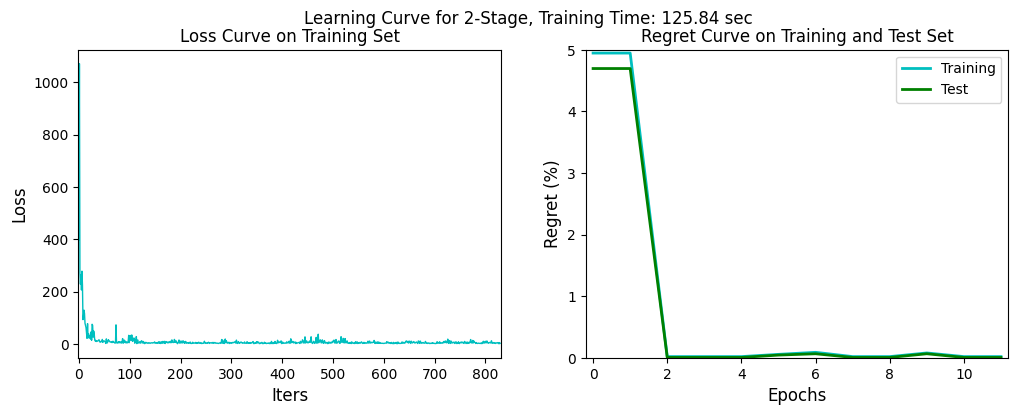

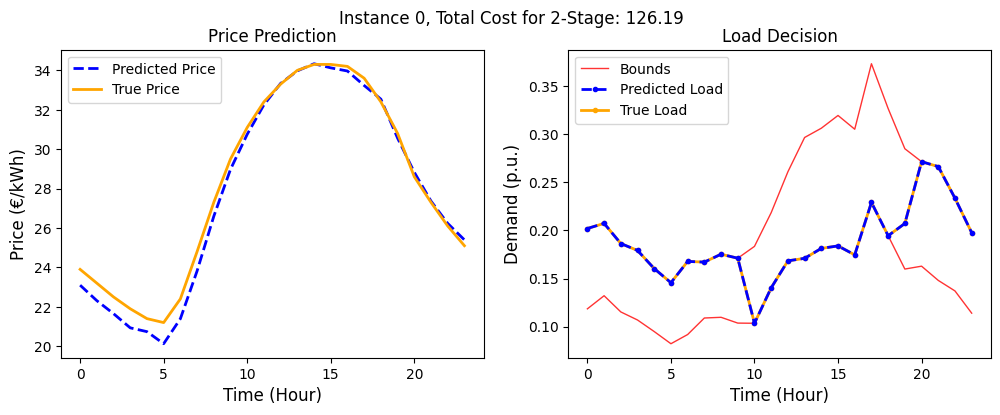





Method: SPO+


Epoch:  9, Loss: 0.0295: 100%|██████████| 10/10 [00:12<00:00,  1.28s/it]


SPO+: Regret on test set: 0.00% after 487.39 sec of training


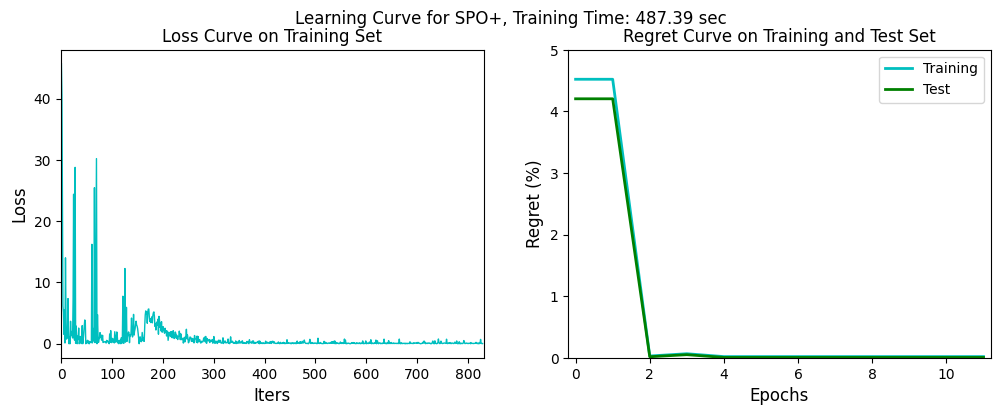

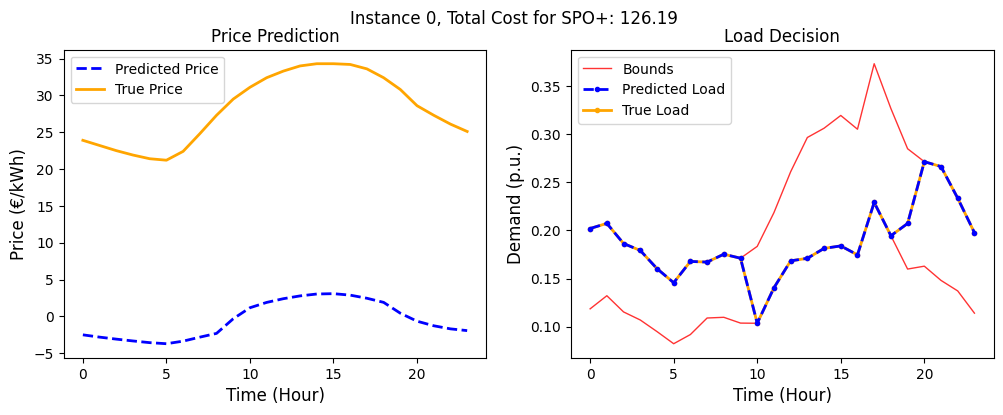





Method: PG


Epoch:  9, Loss: 89.6029: 100%|██████████| 10/10 [00:18<00:00,  1.87s/it]


PG: Regret on test set: 1.76% after 722.75 sec of training


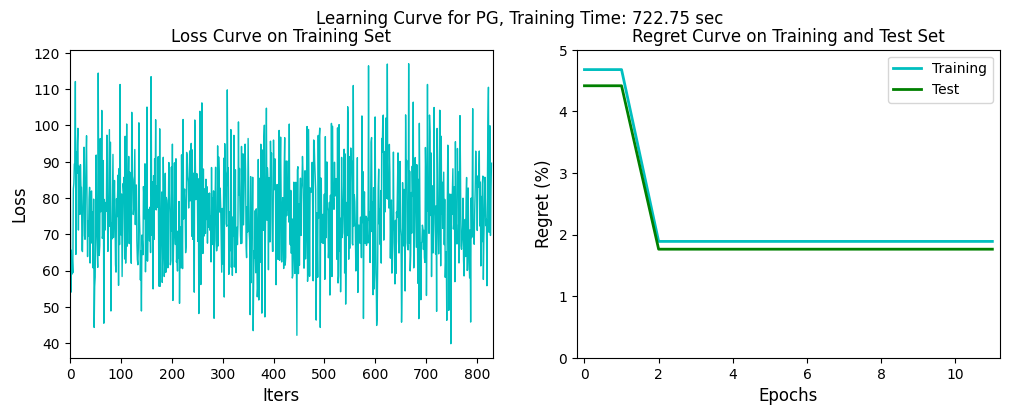

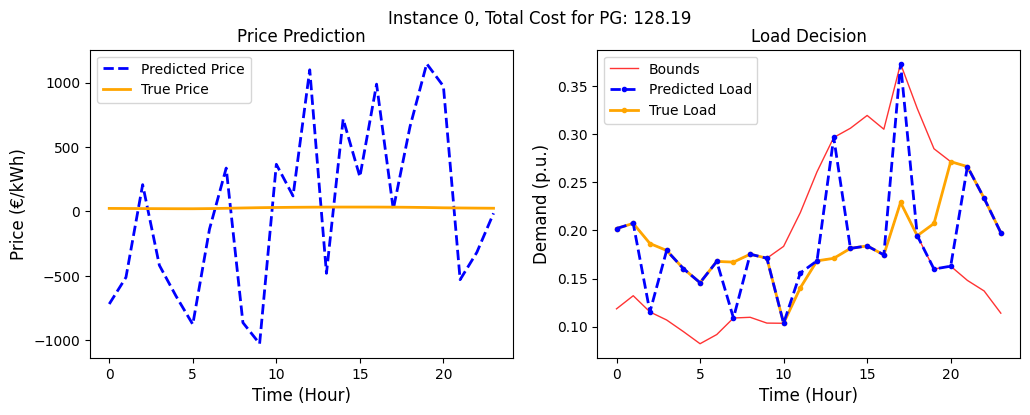





Method: DBB


Epoch:  9, Loss: 0.1811: 100%|██████████| 10/10 [00:20<00:00,  2.05s/it]


DBB: Regret on test set: 0.19% after 820.89 sec of training


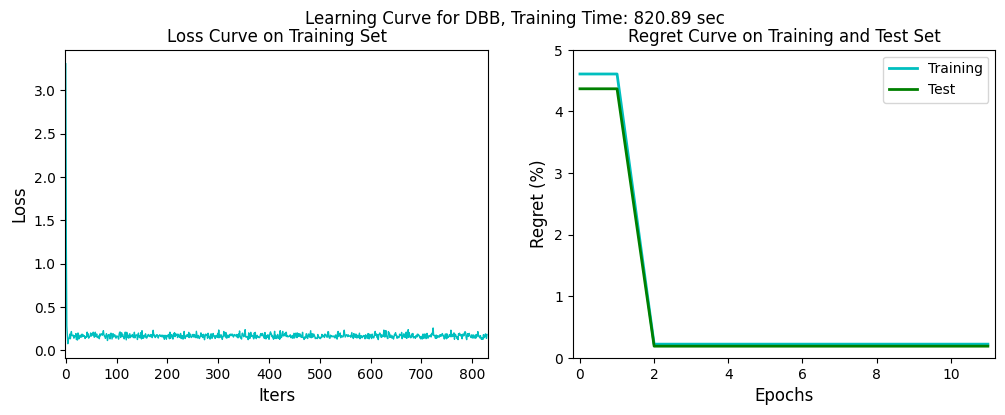

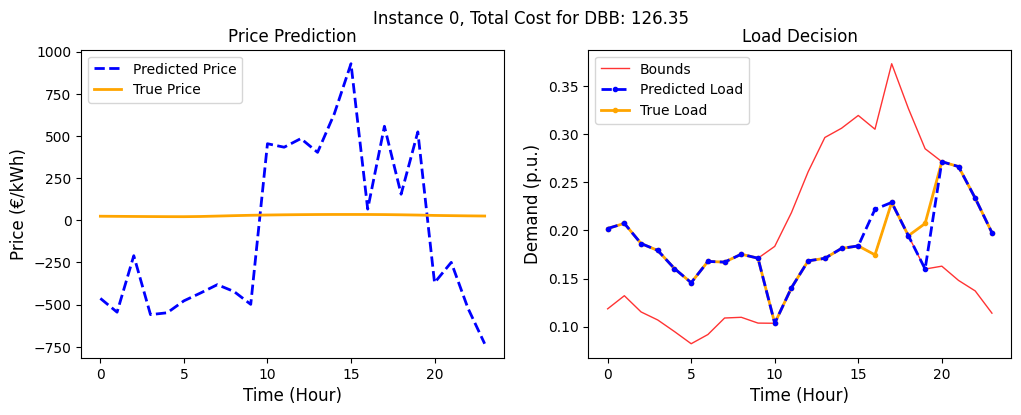





Method: NID


Epoch:  9, Loss: 0.6551: 100%|██████████| 10/10 [00:15<00:00,  1.51s/it]


NID: Regret on test set: 0.80% after 577.55 sec of training


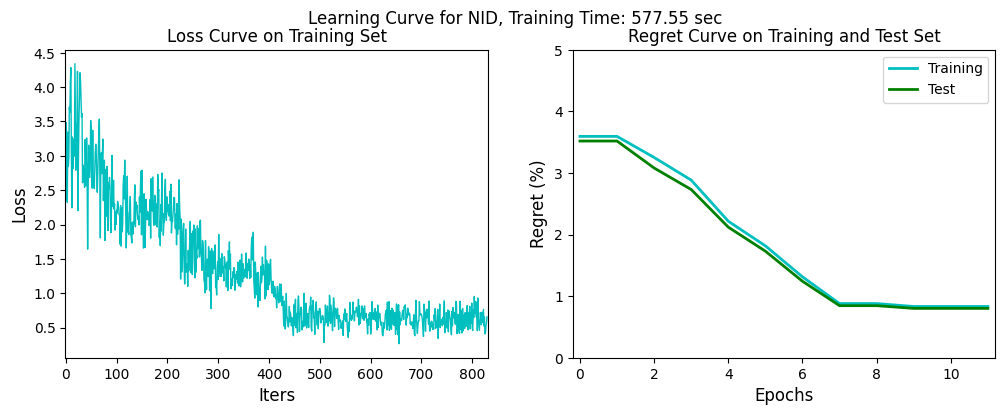

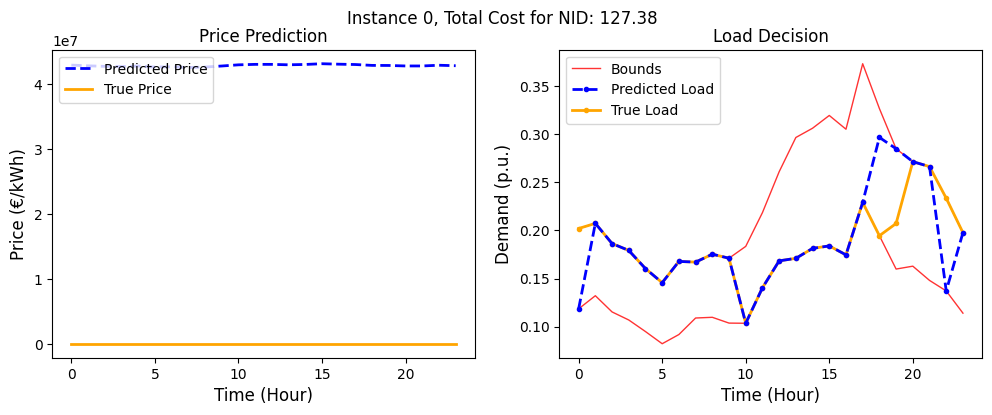





Method: DPO


Epoch:  9, Loss: 0.0025: 100%|██████████| 10/10 [00:16<00:00,  1.60s/it]


DPO: Regret on test set: 0.49% after 617.65 sec of training


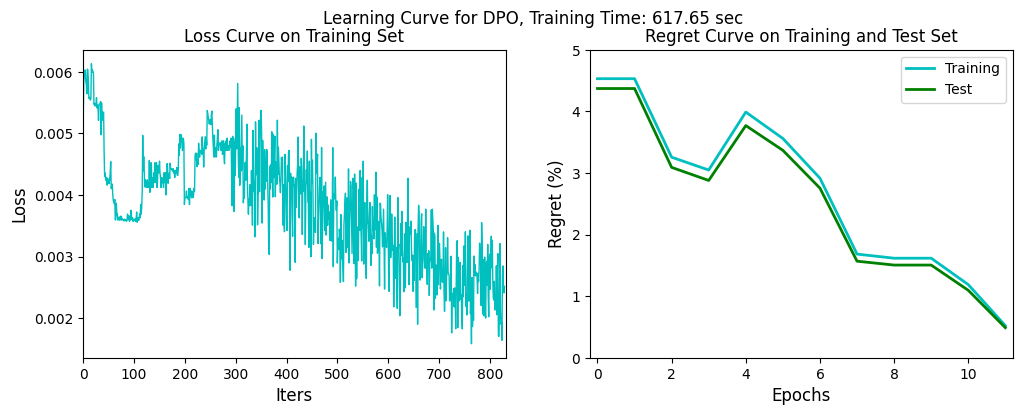

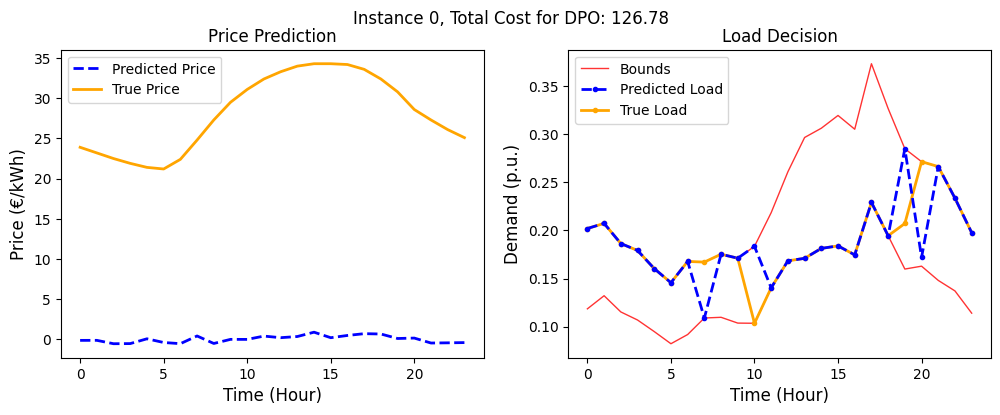





Method: PFYL


Epoch:  9, Loss: -0.0241: 100%|██████████| 10/10 [00:16<00:00,  1.62s/it]


PFYL: Regret on test set: 0.00% after 596.12 sec of training


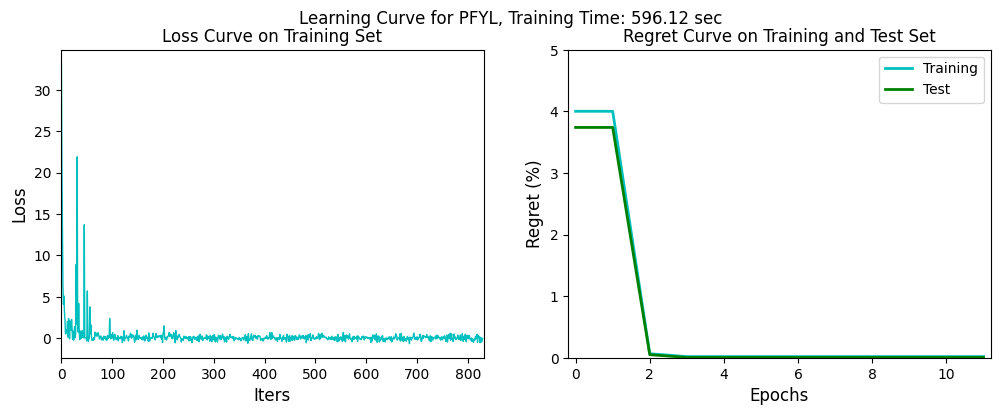

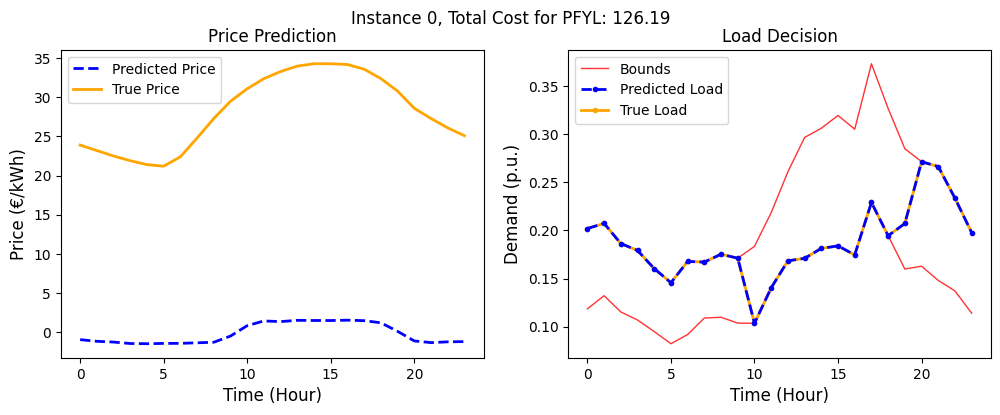





Method: RFWO


Epoch:  9, Loss: 0.0016: 100%|██████████| 10/10 [00:25<00:00,  2.56s/it]


RFWO: Regret on test set: 1.56% after 1021.63 sec of training


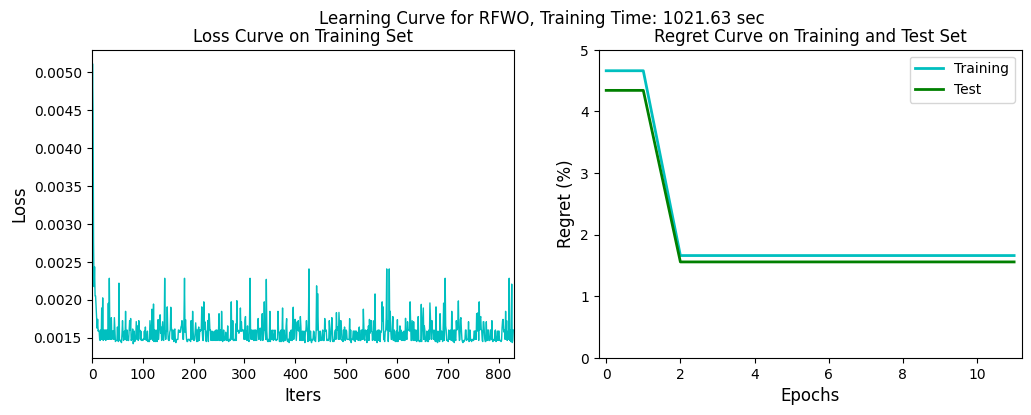

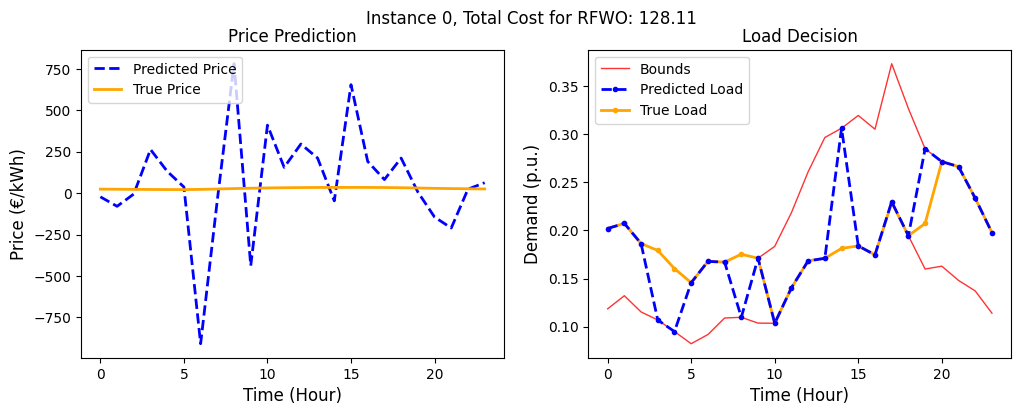





Method: RFYL


Epoch:  9, Loss: 0.0073: 100%|██████████| 10/10 [02:17<00:00, 13.80s/it]


RFYL: Regret on test set: 1.05% after 5651.20 sec of training


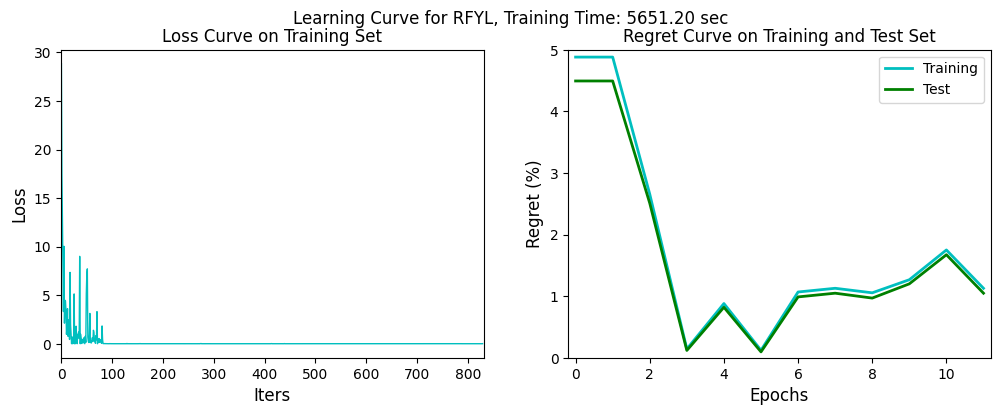

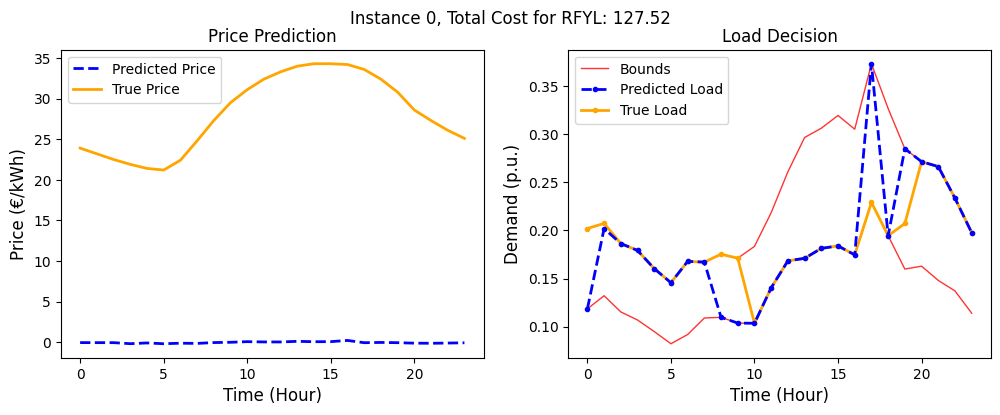





Method: I-MLE


Epoch:  9, Loss: 0.0241: 100%|██████████| 10/10 [00:27<00:00,  2.72s/it]


I-MLE: Regret on test set: 1.77% after 1059.26 sec of training


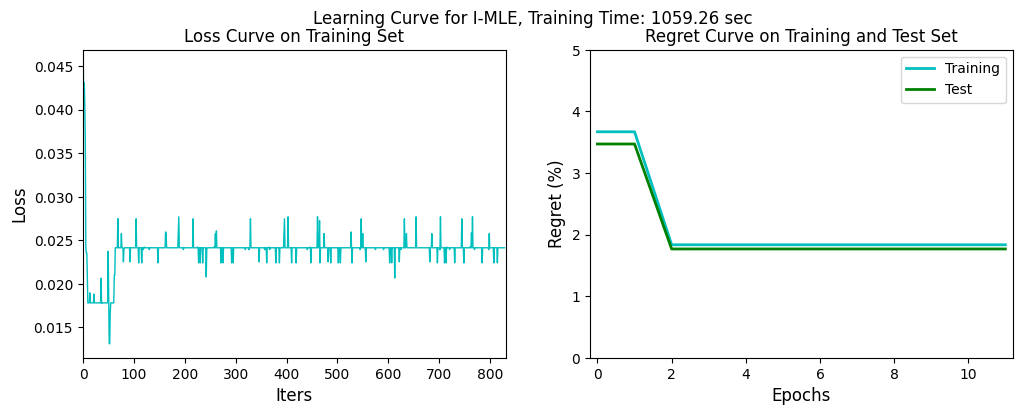

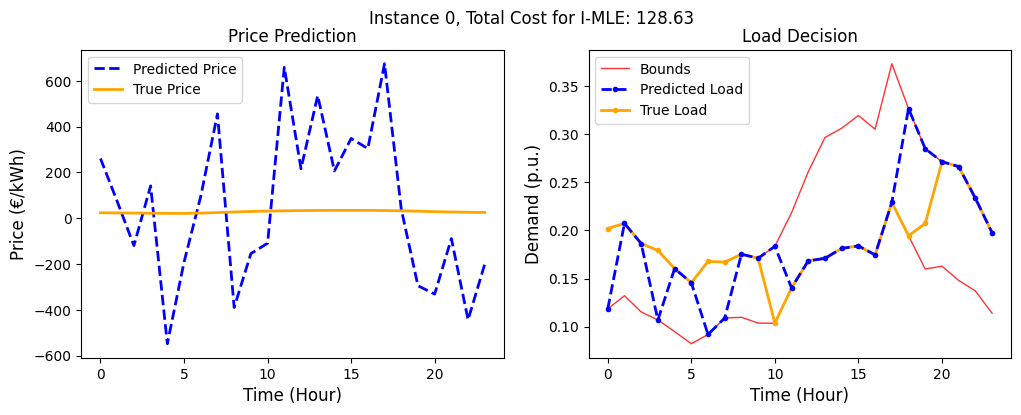





Method: AI-MLE


Epoch:  9, Loss: 0.0069: 100%|██████████| 10/10 [00:29<00:00,  2.95s/it]


AI-MLE: Regret on test set: 0.00% after 1174.79 sec of training


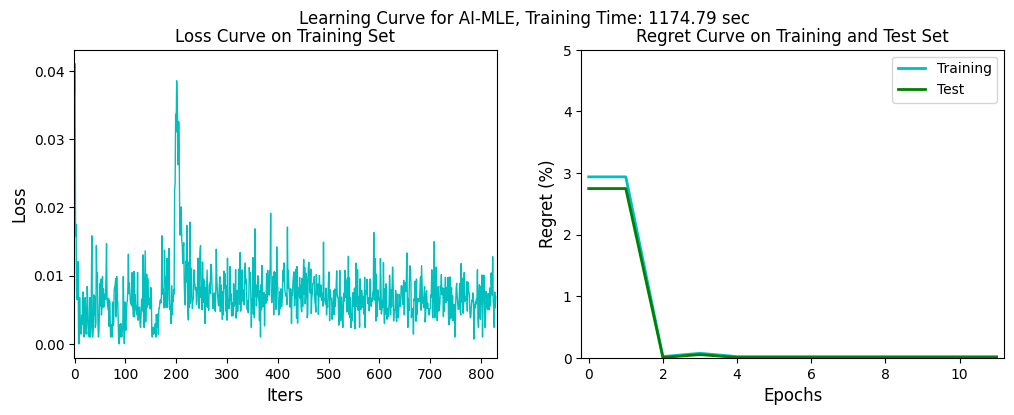

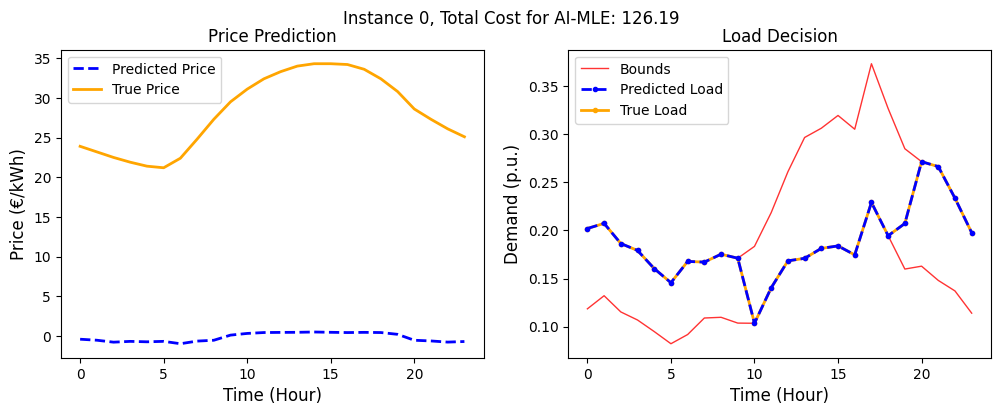





Method: NCE


Epoch:  9, Loss: -5472369.0000: 100%|██████████| 10/10 [00:05<00:00,  1.78it/s]


NCE: Regret on test set: 0.00% after 172.94 sec of training


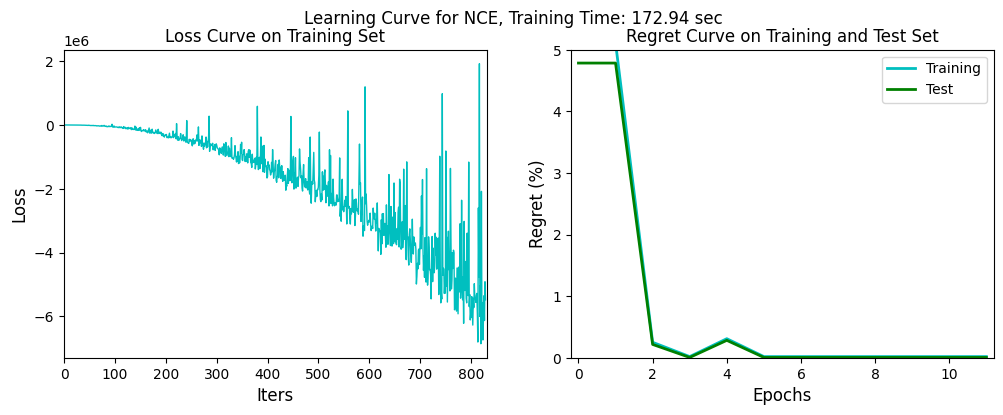

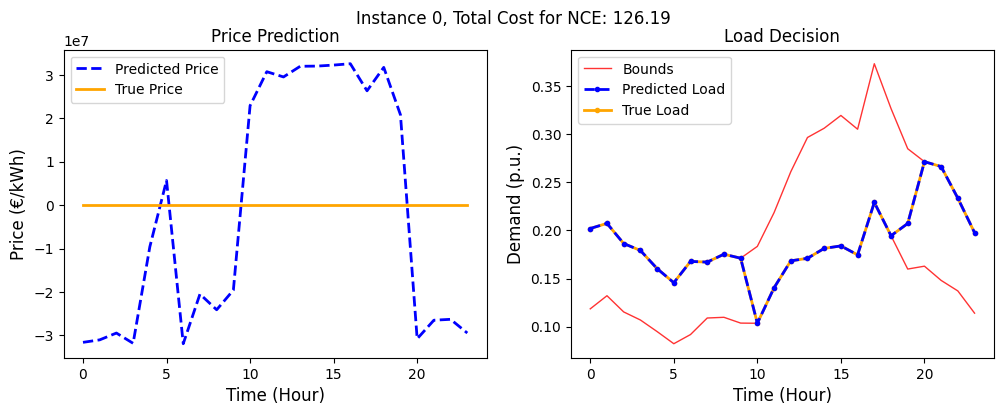





Method: Listwise LTR


Epoch:  9, Loss: 2.9317: 100%|██████████| 10/10 [00:05<00:00,  1.68it/s]


Listwise LTR: Regret on test set: 0.00% after 182.39 sec of training


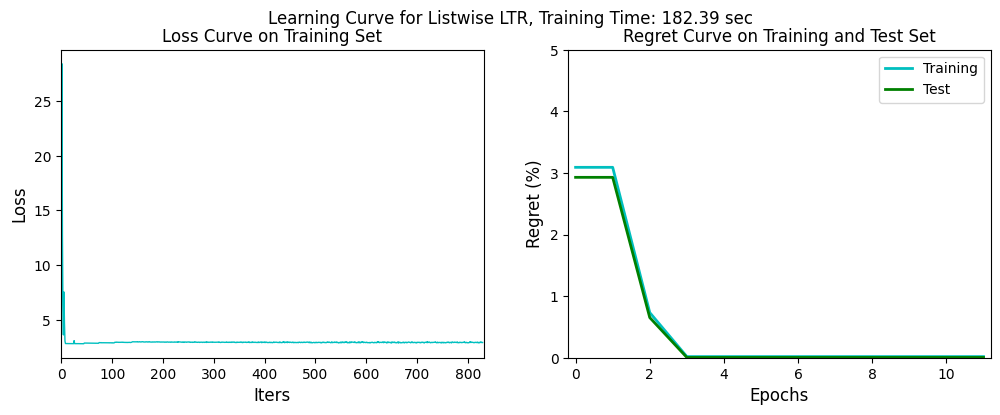

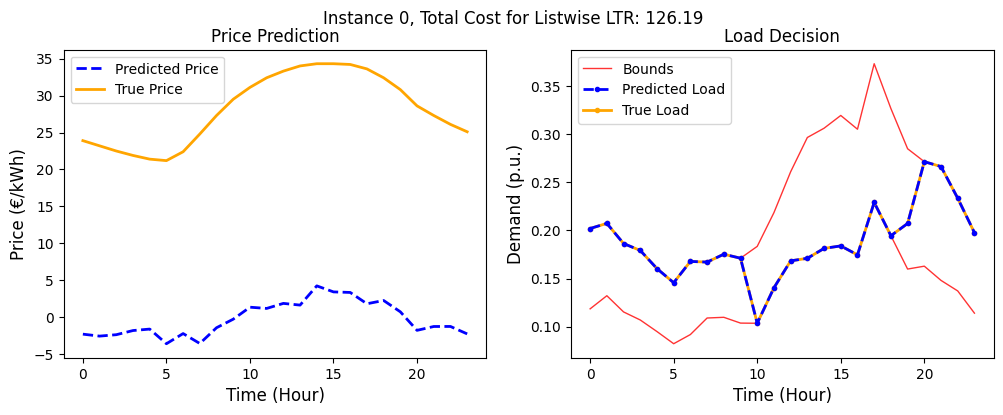





Method: Pairwise LTR


Epoch:  9, Loss: 0.0001: 100%|██████████| 10/10 [00:05<00:00,  1.84it/s]


Pairwise LTR: Regret on test set: 0.14% after 170.63 sec of training


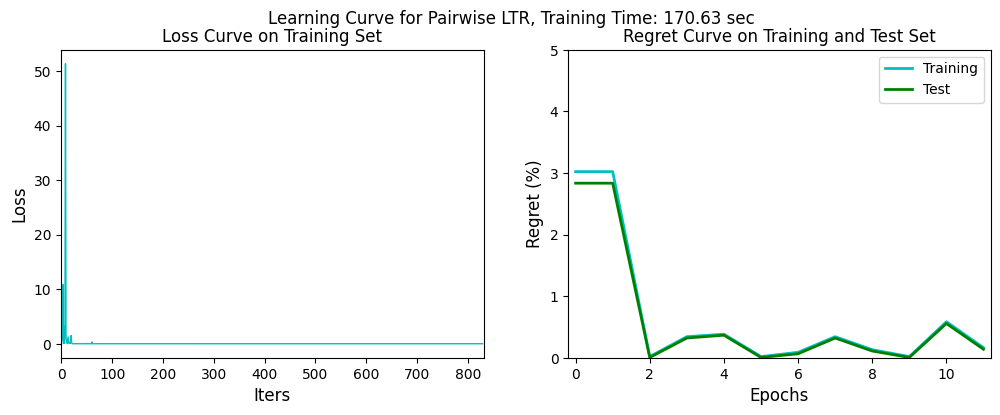

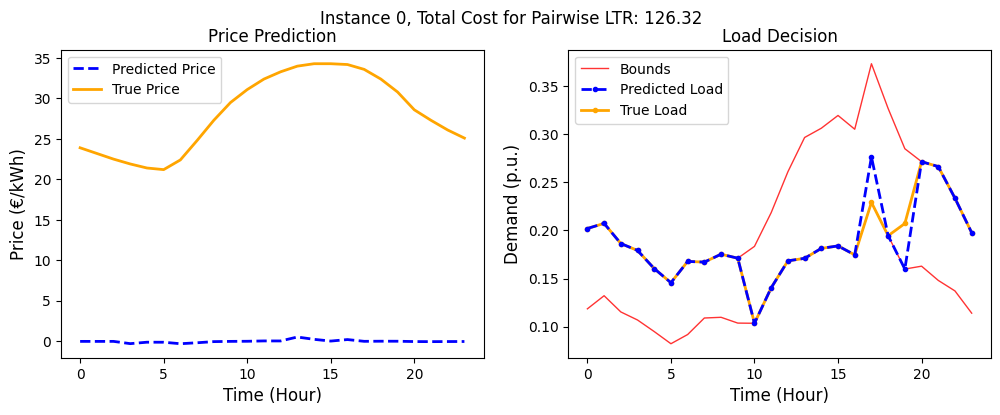





Method: Pointwise LTR


Epoch:  9, Loss: 173.8084: 100%|██████████| 10/10 [00:05<00:00,  1.82it/s]


Pointwise LTR: Regret on test set: 0.31% after 158.88 sec of training


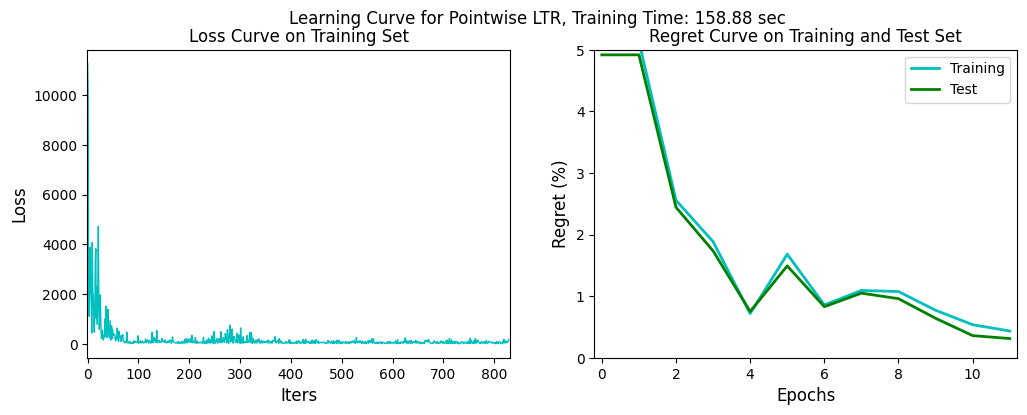

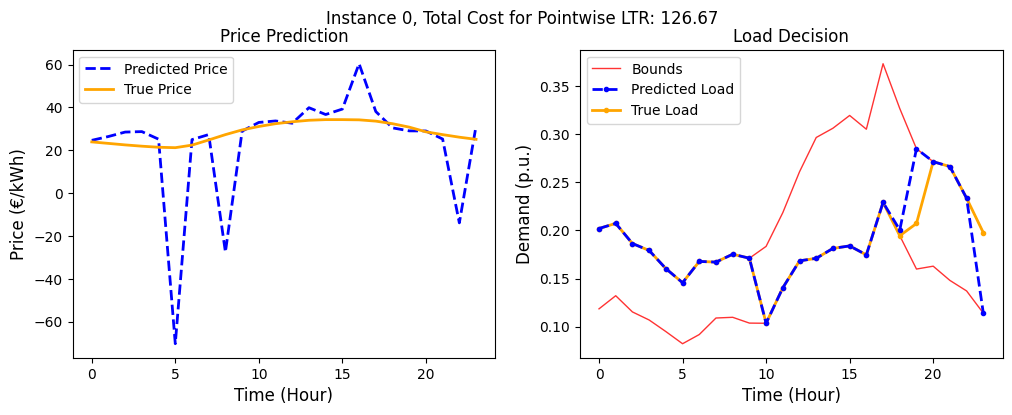

In [25]:
num_processes = 2 # number of cores
num_epochs = 10   # number of epochs
lr = 1e-2         # learning rate
device = "cpu"    # device to use

# autograd functions
func_dict = {
    "2-Stage": nn.MSELoss(),
    "SPO+": pyepo.func.SPOPlus(optmodel, processes=num_processes),
    "PG": pyepo.func.PG(optmodel, sigma=0.1, two_sides=False, processes=num_processes),
    "DBB": pyepo.func.DBB(optmodel, lambd=20, processes=num_processes),
    "NID": pyepo.func.NID(optmodel, processes=num_processes),
    "DPO": pyepo.func.DPO(optmodel, n_samples=1, sigma=0.5, processes=num_processes),
    # "DPO/mul": pyepo.func.DPOMul(optmodel, n_samples=1, sigma=0.5, processes=num_processes),
    "PFYL": pyepo.func.PFY(optmodel, n_samples=1, sigma=0.5, processes=num_processes),
    # "PFYL/mul": pyepo.func.PFYMul(optmodel, n_samples=1, sigma=0.5, processes=num_processes),
    "RFWO": pyepo.func.RFWO(optmodel, lambd=1.0, max_iter=20, tol=1e-6, processes=num_processes),
    "RFYL": pyepo.func.RFY(optmodel, lambd=1.0, max_iter=20, tol=1e-6, processes=num_processes),
    "I-MLE": pyepo.func.IMLE(optmodel, n_samples=1, sigma=0.5, lambd=20, processes=num_processes),
    "AI-MLE": pyepo.func.AIMLE(optmodel, n_samples=1, sigma=0.5, processes=num_processes),
    "NCE": pyepo.func.NCE(optmodel, processes=num_processes, solve_ratio=0.05, dataset=dataset_train),
    "Listwise LTR": pyepo.func.lsLTR(optmodel, processes=num_processes, solve_ratio=0.05, dataset=dataset_train),
    "Pairwise LTR": pyepo.func.prLTR(optmodel, processes=num_processes, solve_ratio=0.05, dataset=dataset_train),
    "Pointwise LTR": pyepo.func.ptLTR(optmodel, processes=num_processes, solve_ratio=0.05, dataset=dataset_train)
}

for method, func in func_dict.items():
    print("Method:", method)
    # init model
    # reg = LinearRegressionNN()
    reg = multiLayerPerceptron(input_dim, hidden_dim, output_dim)
    # training
    logs = trainModel(reg, func, method, loader_train, loader_test, optmodel,
                      device=device, lr=lr, num_epochs=num_epochs)
    # eval
    regret_test = pyepo.metric.regret(reg, optmodel, loader_test)

    # draw plot
    plotLearningCurve(logs, method)
    visSol(plo_t, pup_t, loader_test, optmodel, ind=0, pytorch_model=reg, method_name=method)
    print("\n\n\n")

## Summary

- A realistic predict-then-optimize pipeline: load, price, and climate data are merged into features, the day-ahead scheduling problem is a linear program over flexible demand, and a linear predictor is trained end-to-end against the optimization objective.
- The same PyEPO building blocks — ``dsl`` for the model, ``optDataset`` for the data, and the loss functions in ``pyepo.func`` — carry over unchanged from the synthetic tutorials to real data.
- **Next:** compare training methods in [03 Training and Testing](https://github.com/khalil-research/PyEPO/blob/main/notebooks/03%20Training%20and%20Testing.ipynb), or browse the loss functions in the [documentation](https://khalil-research.github.io/PyEPO/build/html/content/examples/function.html#choosing-a-method).